# 08 — Behavioural Derivations from Orientation and Motion

## What this notebook is for

Five questions, each anchored to a specific, named area of movement or behavioural
science, asked of the same 20-session, 9-participant orientation and motion export used
throughout this project.

| section | theory | the question it asks |
|---|---|---|
| 2 | Hand-tremor / steadiness assessment (clinical motor-control literature) | how much does the hand shake while deliberately holding still, and in what frequency band |
| 3 | Bernstein's degrees-of-freedom problem (motor coordination) | does tilt and roll move as one coupled unit, or independently |
| 4 | The minimum-jerk principle (movement smoothness) | is voluntary movement smooth and continuous, or segmented and corrected in pieces |
| 5 | Muscular fatigue accumulation (ergonomics) | does steadiness get worse over the course of a single session |
| 6 | The orienting response (attention psychology) | does the body react physically to the start of a new task |

Each of these is a real, separately-studied phenomenon with its own literature, not a
family of related statistical tools. Where a computation resembles something from
elsewhere (the tremor-band FFT, for instance, resembles the spectral analysis in an
earlier version of this notebook), it's because the same maths is genuinely the right tool
for that specific, theory-motivated question — not because the technique was tried first
and a justification found afterwards.

No verdict engine, no automated thresholds. Every metric is shown as a plot and a table;
the interpretation stays with the reader. With five evaluable participants this remains
provisional, and every section says so explicitly where it matters.

## 1. Loading the streams

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                      'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = pd.read_parquet(_src)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

ORIENT_KIND, MOTION_KIND = 'deviceorientation', 'devicemotion'
ACCEL_COLS = ['payload_ax', 'payload_ay', 'payload_az']
INTERACTION_KINDS = ['keydown', 'keyup', 'input', 'touchstart', 'touchmove', 'touchend',
                     'scroll', 'window_scroll', 'carousel_scroll', 'pointerdown',
                     'pointerup', 'click']
SAMPLE_HZ = 20.0

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                  .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                       started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

print(f"Loaded {_src}")
print(f"mobile only: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants")

Loaded ../../data/processed/raw_events.parquet
mobile only: 22 sessions, 9 participants


In [2]:
def unwrap_deg(v):
    v = np.asarray(v, float); ok = np.isfinite(v); out = v.copy()
    if ok.sum() > 1:
        out[ok] = np.degrees(np.unwrap(np.radians(v[ok])))
    return out


def break_on_gaps(t, v, max_gap=0.5):
    t = np.asarray(t, float); v = np.asarray(v, float)
    if len(t) < 2:
        return t, v
    dt = np.diff(t)
    gap_idx = np.where(dt > max_gap)[0]
    if len(gap_idx) == 0:
        return t, v
    t_ins = t[gap_idx] + dt[gap_idx] / 2.0
    return np.insert(t, gap_idx + 1, t_ins), np.insert(v, gap_idx + 1, np.nan)


def orientation_series(sess, col='payload_beta'):
    o = sess.loc[sess['kind'] == ORIENT_KIND].sort_values('tRelMs')
    t = o['tRelMs'].to_numpy(float) / 1000.0
    v = pd.to_numeric(o[col], errors='coerce').to_numpy(float)
    if col == 'payload_beta':
        v = unwrap_deg(v)
    ok = np.isfinite(v) & np.isfinite(t)
    return t[ok], v[ok]


def motion_magnitude(sess):
    mo = sess.loc[sess['kind'] == MOTION_KIND].sort_values('tRelMs')
    t = mo['tRelMs'].to_numpy(float) / 1000.0
    mag = np.sqrt(sum(pd.to_numeric(mo[c], errors='coerce').to_numpy(float) ** 2
                       for c in ACCEL_COLS))
    ok = np.isfinite(mag) & np.isfinite(t)
    return t[ok], mag[ok]


def idle_mask(sess, motion_t_ms):
    inter = np.sort(sess.loc[sess['kind'].isin(INTERACTION_KINDS), 'tRelMs'].to_numpy(float))
    if len(inter) == 0:
        return np.ones(len(motion_t_ms), bool)
    idx = np.searchsorted(inter, motion_t_ms)
    prev_gap = np.where(idx > 0, motion_t_ms - inter[np.clip(idx - 1, 0, len(inter) - 1)], np.inf)
    next_gap = np.where(idx < len(inter), inter[np.clip(idx, 0, len(inter) - 1)] - motion_t_ms, np.inf)
    return (prev_gap >= 1000.0) & (next_gap >= 1000.0)


def session_max_gap_s(sess, kind=ORIENT_KIND):
    t = np.sort(sess.loc[sess['kind'] == kind, 'tRelMs'].to_numpy(float)) / 1000.0
    return float(np.diff(t).max()) if len(t) > 1 else np.inf


def session_singularity(sess, col='payload_beta', thresh=75.0):
    _, v = orientation_series(sess, col)
    return len(v) > 0 and abs(float(np.median(v))) > thresh


GAP_EXCLUDE_S = 15.0
_clean_sids = [sid for sid in SESSION_ORDER
               if session_max_gap_s(raw.loc[raw['sessionId'] == sid]) <= GAP_EXCLUDE_S
               and not session_singularity(raw.loc[raw['sessionId'] == sid])]
print(f"clean sessions (excluding long sensor gaps and the beta singularity): "
      f"{len(_clean_sids)} of {len(SESSION_ORDER)}")

clean sessions (excluding long sensor gaps and the beta singularity): 18 of 22


## 2. Steadiness and tremor

Clinical assessment of hand tremor and postural steadiness measures exactly this signal —
accelerometer output from a held device — for exactly this purpose: characterising a
person from how steady their hand is. It is an established, separately-studied field, used
to distinguish healthy motor control from tremor disorders, and known to shift with age
even in healthy adults.

The standard measurement is taken while someone deliberately holds still, which is why
this section restricts itself to idle stretches — moments with no interaction for at least
a second either side — rather than the whole session. Two things are measured, because
they capture different aspects of steadiness:

- **Overall steadiness** — the size of the shake, regardless of its speed: the standard
  deviation of motion magnitude while holding still.
- **Frequency content** — *how fast* the shake is. Physiological (normal, healthy)
  tremor sits around 8-12 Hz. Age-related and pathological tremor tends to sit lower,
  roughly 4-6 Hz, and larger in amplitude. Slow postural sway (the hand gradually drifting)
  sits below 2 Hz and is a different phenomenon again.

**A resolution limit that matters here more than anywhere else in this project:** these
sensors sample at 20 Hz, giving a Nyquist ceiling of 10 Hz. The entire physiological
tremor band (8-12 Hz) sits at or beyond that ceiling. Anything measured there is a coarse
indicator at best, not a clean measurement — this is not a minor caveat for this section,
it is close to the central limitation of what can be asked of this data at all.

In [3]:
MIN_IDLE_RUN = 60


def idle_runs(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        t, mag = motion_magnitude(s)
        if len(t) < 100:
            continue
        im = idle_mask(s, t * 1000.0)
        change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
        for run in np.split(np.arange(len(t)), change):
            if len(run) < MIN_IDLE_RUN or not im[run[0]]:
                continue
            rows.append({'participantId': s['participantId'].iloc[0], 'sessionId': sid,
                         'idx0': run[0], 'idx1': run[-1],
                         'duration_s': t[run[-1]] - t[run[0]]})
    return pd.DataFrame(rows)


runs = idle_runs(raw)
print(f"{len(runs)} idle stretches across {runs['sessionId'].nunique()} sessions, "
      f"{runs['participantId'].nunique()}/{len(PARTICIPANTS)} participants")


def steadiness_and_bands(sid, n_fft=64, hz=SAMPLE_HZ):
    sess = raw.loc[raw['sessionId'] == sid]
    t, mag = motion_magnitude(sess)
    im = idle_mask(sess, t * 1000.0)
    change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
    sds, spec = [], []
    for run in np.split(np.arange(len(t)), change):
        if len(run) < MIN_IDLE_RUN or not im[run[0]]:
            continue
        sds.append(float(np.std(mag[run])))
        if len(run) >= n_fft:
            x = mag[run][:n_fft]; x = x - x.mean()
            pw = np.abs(np.fft.rfft(x)) ** 2
            tot = pw[1:].sum()
            if tot > 0:
                spec.append(pw / tot)
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / hz)
    sway = np.nan; tremor = np.nan
    if spec:
        P = np.mean(spec, axis=0)
        sway_band = (freqs > 0) & (freqs <= 2)
        tremor_band = (freqs >= 8) & (freqs <= 9.5)  # truncated at Nyquist, see note above
        sway = float(P[sway_band].sum())
        tremor = float(P[tremor_band].sum())
    return (float(np.median(sds)) if sds else np.nan), sway, tremor, len(sds)


rows = []
for sid in SESSION_ORDER:
    steadiness, sway_pw, tremor_pw, n = steadiness_and_bands(sid)
    rows.append({'p': raw.loc[raw['sessionId'] == sid, 'participantId'].iloc[0],
                 'session': SESSION_LABEL[sid], 'n_idle_epochs': n,
                 'steadiness_sd': round(steadiness, 3),
                 'sway_power_lt2hz': round(sway_pw, 3) if np.isfinite(sway_pw) else np.nan,
                 'tremor_power_8to9_5hz': round(tremor_pw, 3) if np.isfinite(tremor_pw) else np.nan})
steady_df = pd.DataFrame(rows)
print(steady_df.drop(columns='p').to_string(index=False))

115 idle stretches across 13 sessions, 9/9 participants
   session  n_idle_epochs  steadiness_sd  sway_power_lt2hz  tremor_power_8to9_5hz
p3M6E7Z s1             32          0.091             0.374                  0.103
p3YDMHG s1              3          0.053             0.409                  0.128
p3YDMHG s2             10          0.063             0.361                  0.160
p95MPVX s1              9          0.131             0.447                  0.087
p95MPVX s2              4          0.197             0.335                  0.204
pA6XL23 s1             13          0.114             0.469                  0.083
pA6XL23 s2              4          0.268             0.345                  0.153
pAFQRTM s1             13          0.118             0.406                  0.102
pG5G4MS s1              0            NaN               NaN                    NaN
pG5G4MS s2              0            NaN               NaN                    NaN
pG5G4MS s3              0            NaN  

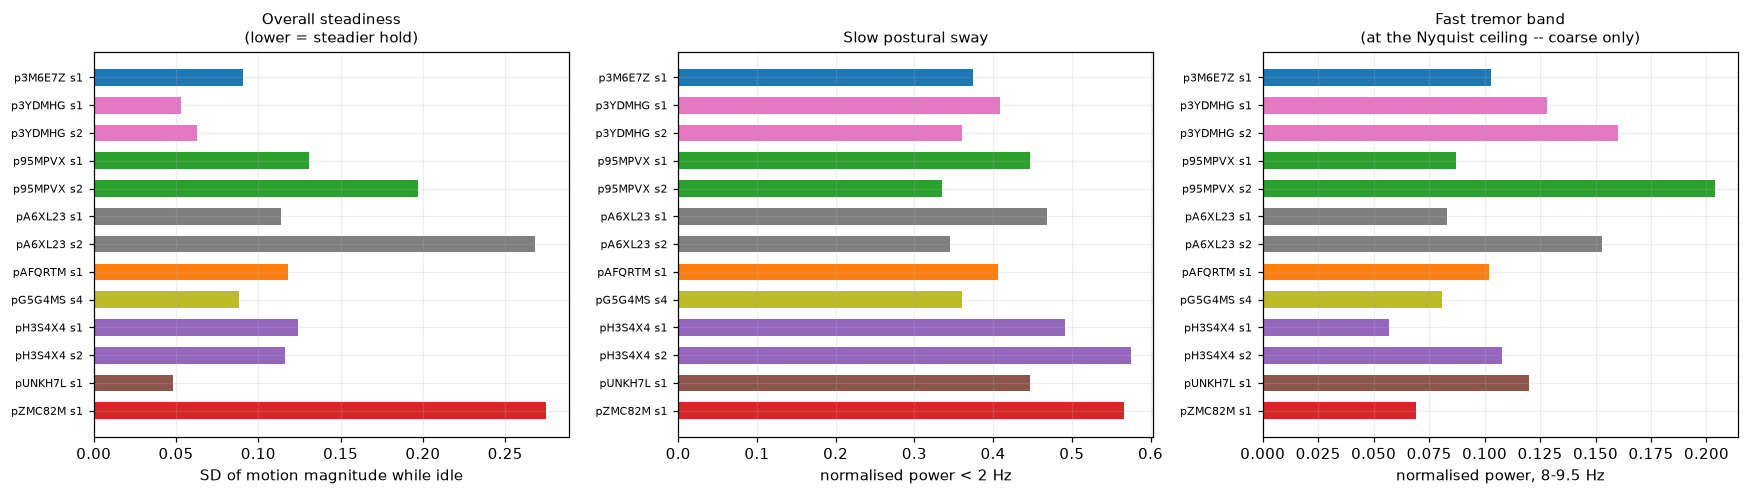

In [4]:
def plot_steadiness(steady_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    d = steady_df.dropna(subset=['steadiness_sd']).sort_values(['p', 'session'])
    ax = axes[0]
    y = np.arange(len(d))
    ax.barh(y, d['steadiness_sd'], color=[pcolor(p) for p in d['p']], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(d['session'], fontsize=7); ax.invert_yaxis()
    ax.set_xlabel("SD of motion magnitude while idle")
    ax.set_title("Overall steadiness\n(lower = steadier hold)", fontsize=10)

    d2 = steady_df.dropna(subset=['sway_power_lt2hz']).sort_values(['p', 'session'])
    ax = axes[1]
    y = np.arange(len(d2))
    ax.barh(y, d2['sway_power_lt2hz'], color=[pcolor(p) for p in d2['p']], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(d2['session'], fontsize=7); ax.invert_yaxis()
    ax.set_xlabel("normalised power < 2 Hz")
    ax.set_title("Slow postural sway", fontsize=10)

    ax = axes[2]
    ax.barh(y, d2['tremor_power_8to9_5hz'], color=[pcolor(p) for p in d2['p']], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(d2['session'], fontsize=7); ax.invert_yaxis()
    ax.set_xlabel("normalised power, 8-9.5 Hz")
    ax.set_title("Fast tremor band\n(at the Nyquist ceiling -- coarse only)", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_steadiness(steady_df)

## 3. Motor coordination — coupled or independent movement

Bernstein's classic account of motor skill describes a "degrees of freedom problem":
novice or effortful movement tends to *freeze* multiple joints together and move them as
a single rigid unit, while skilled or relaxed movement *releases* those joints and
coordinates them independently. This is a well-established developmental and skill-related
axis in motor control, not a statistical analogy.

Applied here: when the phone reorients, does tilt (beta) and roll (gamma) change together
— a single coupled repositioning — or independently, as if the two axes were being
adjusted separately? This is measured as a rolling correlation between how fast beta is
changing and how fast gamma is changing.

Coordination theory is specifically about *voluntary* movement, so this is computed
separately for active (task-engaged) and idle stretches — the two are expected to differ,
and conflating them would blur the thing being measured.

In [5]:
ROLL_WINDOW_S = 5.0


def cross_axis_coupling(sess, active_only=None, window_s=ROLL_WINDOW_S, hz=SAMPLE_HZ):
    t_b, b = orientation_series(sess, 'payload_beta')
    t_g, g = orientation_series(sess, 'payload_gamma')
    n = min(len(b), len(g))
    if n < 200:
        return np.array([]), np.array([])
    b, g = b[:n], g[:n]
    t = t_b[:n]
    db = np.diff(b); dg = np.diff(g)
    win = max(10, int(round(window_s * hz)))
    corr = pd.Series(db).rolling(win, min_periods=win // 2).corr(pd.Series(dg)).to_numpy()
    t_mid = t[1:]
    if active_only is not None:
        im = idle_mask(sess, t_mid * 1000.0)
        mask = (~im) if active_only else im
        return t_mid[mask], corr[mask]
    return t_mid, corr


rows = []
for sid in _clean_sids:
    sess = raw.loc[raw['sessionId'] == sid]
    _, corr_active = cross_axis_coupling(sess, active_only=True)
    _, corr_idle = cross_axis_coupling(sess, active_only=False)
    rows.append({'p': sess['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                 'coupling_active': round(float(np.nanmedian(corr_active)), 2) if len(corr_active) else np.nan,
                 'coupling_idle': round(float(np.nanmedian(corr_idle)), 2) if len(corr_idle) else np.nan})
coup_df = pd.DataFrame(rows)
print(f"Median rolling correlation between beta-change and gamma-change ({ROLL_WINDOW_S:.0f}s window),")
print("split by whether the person was actively using the app at that moment:")
print(coup_df.drop(columns='p').to_string(index=False))

Median rolling correlation between beta-change and gamma-change (5s window),
split by whether the person was actively using the app at that moment:
   session  coupling_active  coupling_idle
p3YDMHG s1             0.23           0.33
p3YDMHG s2             0.43           0.17
p95MPVX s1             0.60           0.61
pA6XL23 s1             0.23           0.10
pA6XL23 s2             0.15           0.05
pAFQRTM s1             0.01           0.01
pG5G4MS s1             0.42           0.28
pG5G4MS s2             0.53           0.25
pG5G4MS s3             0.36           0.46
pG5G4MS s4             0.43           0.37
pG5G4MS s5             0.43           0.29
pH3S4X4 s1             0.71           0.66
pH3S4X4 s2             0.68           0.74
pH3S4X4 s3             0.66           0.62
pH3S4X4 s5             0.67           0.88
pH3S4X4 s6             0.76           0.85
pH3S4X4 s7             0.63           0.05
pUNKH7L s1             0.69           0.56


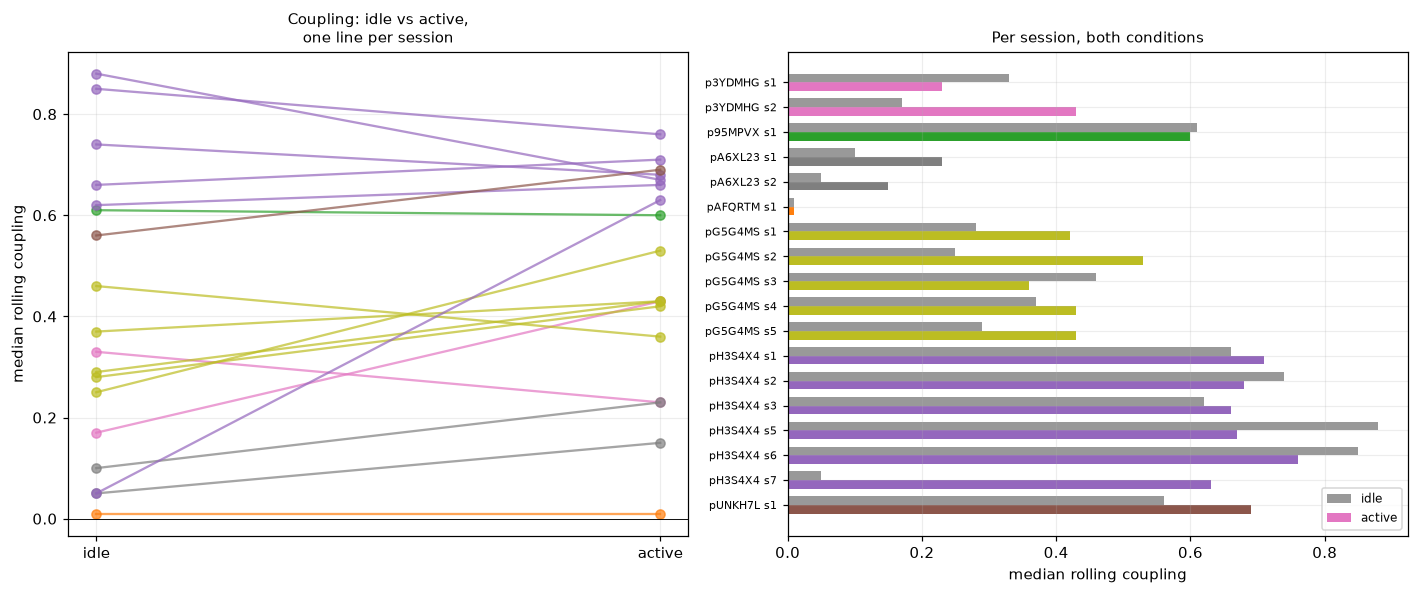

In [6]:
def plot_coupling(coup_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    ax = axes[0]
    d = coup_df.dropna(subset=['coupling_active', 'coupling_idle'])
    for _, r in d.iterrows():
        ax.plot([0, 1], [r['coupling_idle'], r['coupling_active']], '-o',
                color=pcolor(r['p']), alpha=0.7, markersize=6)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['idle', 'active'])
    ax.axhline(0, color='k', lw=0.6)
    ax.set_ylabel("median rolling coupling")
    ax.set_title("Coupling: idle vs active,\none line per session", fontsize=10)

    ax = axes[1]
    order = coup_df.sort_values(['p', 'session'])
    y = np.arange(len(order))
    w = 0.35
    ax.barh(y - w / 2, order['coupling_idle'], height=w, color='0.6', label='idle')
    ax.barh(y + w / 2, order['coupling_active'], height=w,
            color=[pcolor(p) for p in order['p']], label='active')
    ax.set_yticks(y); ax.set_yticklabels(order['session'], fontsize=7); ax.invert_yaxis()
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel("median rolling coupling")
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title("Per session, both conditions", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_coupling(coup_df)

## 4. Movement smoothness

Voluntary human movement is not simply whatever is fastest — the nervous system
specifically optimises for *smoothness*, minimising the rate of change of acceleration
(jerk) during reaching and manipulation movements. This is the minimum-jerk principle, one
of the best-established quantitative findings in motor control. Movement that is less
smooth — more segmented, more corrected in pieces rather than flowing continuously — is
associated with degraded motor control: fatigue, age, or reduced skill with a task.

This is a property of *active* movement, so it is computed only during task-engaged
stretches, not idle holding. The measure used is a normalised jerk: the size of jerk
relative to the size of the movement producing it. A high ratio means small, choppy
corrections; a low ratio means large, fluid, continuous motion.

In [7]:
def active_runs(sess, min_len=40):
    t, mag = motion_magnitude(sess)
    if len(t) < 100:
        return []
    im = idle_mask(sess, t * 1000.0)
    active = ~im
    change = np.where(np.diff(active.astype(int)) != 0)[0] + 1
    runs = []
    for run in np.split(np.arange(len(t)), change):
        if len(run) >= min_len and active[run[0]]:
            runs.append(run)
    return t, mag, runs


def normalised_jerk(sid):
    sess = raw.loc[raw['sessionId'] == sid]
    t, mag, runs = active_runs(sess)
    if not runs:
        return np.nan, 0
    ratios = []
    for run in runs:
        seg_t, seg_m = t[run], mag[run]
        dt = np.diff(seg_t); dt[dt <= 0] = np.nan
        jerk = np.diff(seg_m) / dt
        rms_jerk = np.sqrt(np.nanmean(jerk ** 2))
        rms_mag = np.sqrt(np.mean(seg_m ** 2))
        if rms_mag > 0 and np.isfinite(rms_jerk):
            ratios.append(rms_jerk / rms_mag)
    return (float(np.median(ratios)) if ratios else np.nan), len(ratios)


# Motion-only measure -- doesn't touch beta/gamma, so it uses every session
# rather than the orientation-specific _clean_sids filter (consistent with
# Sections 2, 5 and 6, which are also motion-only).
rows = []
for sid in SESSION_ORDER:
    ratio, n = normalised_jerk(sid)
    rows.append({'p': raw.loc[raw['sessionId'] == sid, 'participantId'].iloc[0],
                 'session': SESSION_LABEL[sid], 'n_active_bursts': n,
                 'normalised_jerk': round(ratio, 2) if np.isfinite(ratio) else np.nan})
jerk_df = pd.DataFrame(rows)
print("Normalised jerk during active (task-engaged) movement --")
print("higher = choppier, more corrected-in-pieces movement:")
print(jerk_df.drop(columns='p').to_string(index=False))
_jr = jerk_df['normalised_jerk'].dropna()
print(f"\nrange across the whole cohort: {_jr.min():.2f} to {_jr.max():.2f} "
      f"({100*(_jr.max()-_jr.min())/_jr.median():.0f}% of the median)")
print("This range is narrow relative to every other measure in this notebook. A likely")
print("cause: differencing a signal amplifies high-frequency noise, and at 20Hz sample-to-")
print("sample sensor noise may dominate over genuine behavioural smoothness differences.")
print("The standard fix in the smoothness literature is to low-pass filter before")
print("differentiating -- not done here, so this measure should be treated as unverified")
print("until that is tried.")

Normalised jerk during active (task-engaged) movement --
higher = choppier, more corrected-in-pieces movement:
   session  n_active_bursts  normalised_jerk
p3M6E7Z s1               71            12.12
p3YDMHG s1               25            11.86
p3YDMHG s2               38            11.03
p95MPVX s1               53            11.15
p95MPVX s2               26            11.69
pA6XL23 s1               26            12.31
pA6XL23 s2               18            13.29
pAFQRTM s1               65            12.02
pG5G4MS s1                4            12.00
pG5G4MS s2                3            12.13
pG5G4MS s3                2            12.57
pG5G4MS s4                8            12.04
pG5G4MS s5                4            12.51
pH3S4X4 s1               54            11.95
pH3S4X4 s2               29            12.80
pH3S4X4 s3               15            13.88
pH3S4X4 s4               13            11.78
pH3S4X4 s5                9            13.10
pH3S4X4 s6               10       

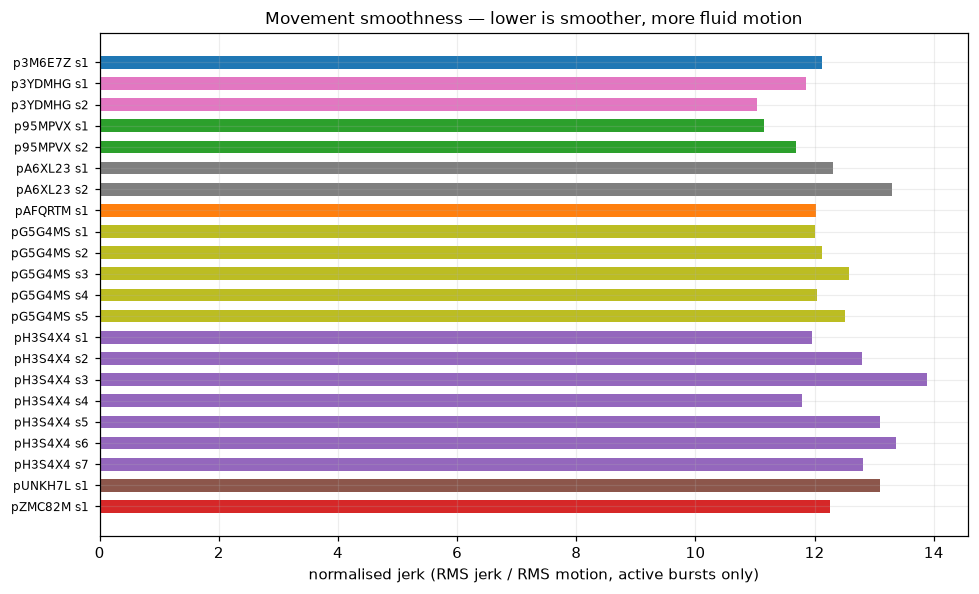

In [8]:
def plot_jerk(jerk_df):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    d = jerk_df.dropna(subset=['normalised_jerk']).sort_values(['p', 'session'])
    y = np.arange(len(d))
    ax.barh(y, d['normalised_jerk'], color=[pcolor(p) for p in d['p']], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(d['session'], fontsize=8); ax.invert_yaxis()
    ax.set_xlabel("normalised jerk (RMS jerk / RMS motion, active bursts only)")
    ax.set_title("Movement smoothness — lower is smoother, more fluid motion")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_jerk(jerk_df)

## 5. Fatigue accumulation within a session

Sustained holding of a phone is a small isometric task, and ergonomics research is
consistent that muscles progressively tire under sustained load, producing more frequent
micro-adjustments as time goes on. This is a genuinely different question from anything
elsewhere in this project: not a comparison *between* sessions, but a trend *within* one
recording — does steadiness get worse from the first few minutes to the last few minutes
of the same sitting?

Each session is split into four equal time quarters, and idle steadiness (Section 2's
measure) is computed separately within each quarter.

Idle steadiness (SD of motion magnitude) in each quarter of the session:
   session    q1    q2    q3    q4
p3M6E7Z s1 0.456 0.332 0.157 0.263
p3YDMHG s1 0.099 0.066 0.077 0.051
p3YDMHG s2 0.069 0.101 0.089 0.085
p95MPVX s1 0.116 0.140 0.228 0.394
p95MPVX s2 0.087 0.759 0.091 0.191
pA6XL23 s1 0.241 0.163 0.289 0.107
pA6XL23 s2 0.440 0.149 0.074 0.364
pAFQRTM s1 0.534 0.167 1.107 0.232
pG5G4MS s1   NaN   NaN   NaN   NaN
pG5G4MS s2   NaN   NaN   NaN   NaN
pG5G4MS s3 0.126   NaN   NaN   NaN
pG5G4MS s4 0.149 0.394   NaN   NaN
pG5G4MS s5 0.191   NaN   NaN   NaN
pH3S4X4 s1 0.162 0.166 0.084 0.091
pH3S4X4 s2 0.140 0.086 0.133 0.048
pH3S4X4 s3 0.054 0.081   NaN 0.170
pH3S4X4 s4 0.061 0.027 0.297 0.055
pH3S4X4 s5 0.058   NaN 0.301   NaN
pH3S4X4 s6   NaN 0.044 0.167 0.102
pH3S4X4 s7   NaN   NaN   NaN   NaN
pUNKH7L s1 0.353 0.438 0.101 0.047
pZMC82M s1 0.226 0.259 0.441 0.356


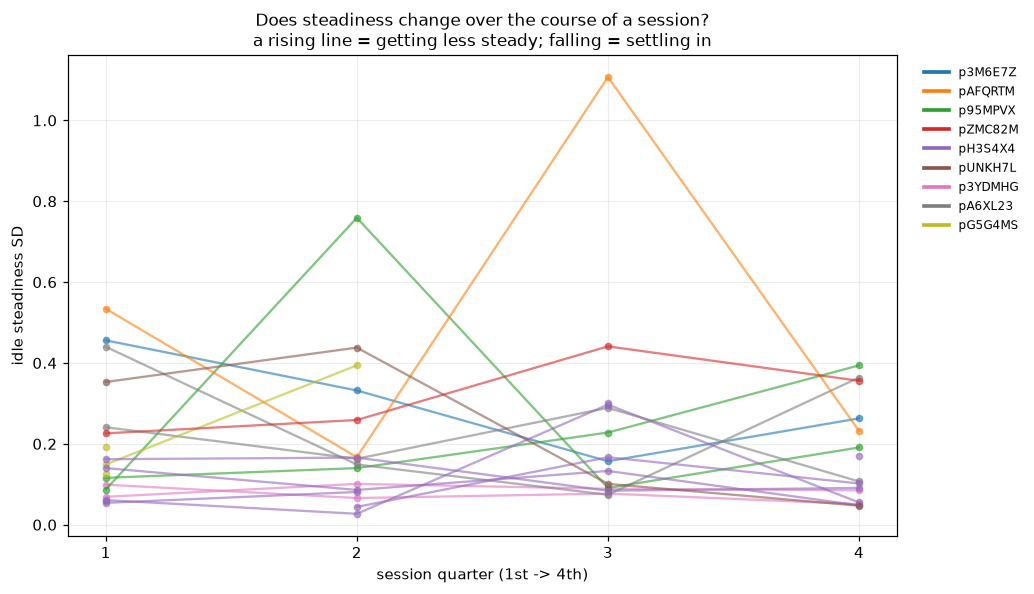

In [9]:
N_QUARTILES = 4


def steadiness_by_quartile(sid, n_q=N_QUARTILES):
    sess = raw.loc[raw['sessionId'] == sid]
    t, mag = motion_magnitude(sess)
    if len(t) < 200:
        return [np.nan] * n_q
    im = idle_mask(sess, t * 1000.0)
    dur = t.max()
    edges = np.linspace(0, dur, n_q + 1)
    out = []
    for i in range(n_q):
        m = (t >= edges[i]) & (t < edges[i + 1]) & im
        out.append(float(np.std(mag[m])) if m.sum() >= 20 else np.nan)
    return out


rows = []
for sid in SESSION_ORDER:
    vals = steadiness_by_quartile(sid)
    rows.append({'p': raw.loc[raw['sessionId'] == sid, 'participantId'].iloc[0],
                 'session': SESSION_LABEL[sid],
                 **{f'q{i+1}': round(v, 3) if np.isfinite(v) else np.nan for i, v in enumerate(vals)}})
fatigue_df = pd.DataFrame(rows)
print("Idle steadiness (SD of motion magnitude) in each quarter of the session:")
print(fatigue_df.drop(columns='p').to_string(index=False))


def plot_fatigue(fatigue_df):
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    qcols = [f'q{i+1}' for i in range(N_QUARTILES)]
    for _, r in fatigue_df.iterrows():
        vals = [r[c] for c in qcols]
        if all(pd.isna(v) for v in vals):
            continue
        ax.plot(range(1, N_QUARTILES + 1), vals, '-o', color=pcolor(r['p']),
                alpha=0.6, markersize=4)
    ax.set_xticks(range(1, N_QUARTILES + 1))
    ax.set_xlabel("session quarter (1st -> 4th)")
    ax.set_ylabel("idle steadiness SD")
    ax.set_title("Does steadiness change over the course of a session?\n"
                 "a rising line = getting less steady; falling = settling in")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_fatigue(fatigue_df)

## 6. Around a task transition — motion before and after

When something new demands attention, a common finding in attention psychology is a small
physical adjustment right at the moment of the change — leaning in, re-gripping, a brief
shift in posture (the "orienting response"), a reaction known to diminish with age and
attentiveness. That was the motivating question here.

Every session in this dataset contains 26 task-start events at known timestamps, giving a
clean, repeated marker to test it against: how does motion in the second after a new task
begins compare to the second before it?

In [10]:
PRE_WINDOW_S = 1.0
POST_WINDOW_S = 1.0


def task_start_times(sess):
    ts = sess.loc[sess['kind'] == 'task_start', 'tRelMs'].to_numpy(float) / 1000.0
    return np.sort(ts)


def orienting_response(sid, pre_s=PRE_WINDOW_S, post_s=POST_WINDOW_S):
    sess = raw.loc[raw['sessionId'] == sid]
    t, mag = motion_magnitude(sess)
    starts = task_start_times(sess)
    if len(t) < 100 or len(starts) == 0:
        return np.nan, 0
    ratios = []
    for s0 in starts:
        pre = mag[(t >= s0 - pre_s) & (t < s0)]
        post = mag[(t >= s0) & (t < s0 + post_s)]
        if len(pre) >= 5 and len(post) >= 5:
            rms_pre = np.sqrt(np.mean(pre ** 2))
            rms_post = np.sqrt(np.mean(post ** 2))
            if rms_pre > 0:
                ratios.append(rms_post / rms_pre)
    return (float(np.median(ratios)) if ratios else np.nan), len(ratios)


rows = []
example_traces = {}
for sid in SESSION_ORDER:
    ratio, n = orienting_response(sid)
    rows.append({'p': raw.loc[raw['sessionId'] == sid, 'participantId'].iloc[0],
                 'session': SESSION_LABEL[sid], 'n_transitions': n,
                 'post_pre_ratio': round(ratio, 2) if np.isfinite(ratio) else np.nan})
orient_df = pd.DataFrame(rows)
print(f"Motion RMS in the {POST_WINDOW_S:.0f}s after a task starts, relative to the "
      f"{PRE_WINDOW_S:.0f}s before it:")
print(orient_df.drop(columns='p').to_string(index=False))
print(f"\nEvery single session falls below 1.0 -- the opposite of the naive hypothesis")
print(f"that a new task produces a motion bump. Checking why, rather than just reporting")
print(f"it: does the 'pre' window actually capture a quiet baseline, or does it capture")
print(f"the interaction that ends the *previous* task (the tap that triggers the")
print(f"transition in the first place)?")

_sess0 = raw.loc[raw['sessionId'] == SESSION_ORDER[0]]
_starts0 = task_start_times(_sess0)
_inter0 = np.sort(_sess0.loc[_sess0['kind'].isin(INTERACTION_KINDS), 'tRelMs'].to_numpy(float) / 1000.0)
print(f"\n{SESSION_LABEL[SESSION_ORDER[0]]}, first 5 transitions -- interaction event count")
print("in the second immediately before vs immediately after each one:")
for s0 in _starts0[:5]:
    n_before = int(((_inter0 >= s0 - 1) & (_inter0 < s0)).sum())
    n_after = int(((_inter0 >= s0) & (_inter0 < s0 + 1)).sum())
    print(f"  t={s0:6.1f}s   before: {n_before:2d} interactions   after: {n_after:2d} interactions")

Motion RMS in the 1s after a task starts, relative to the 1s before it:
   session  n_transitions  post_pre_ratio
p3M6E7Z s1             26            0.86
p3YDMHG s1             25            0.66
p3YDMHG s2             26            0.61
p95MPVX s1             26            0.71
p95MPVX s2             26            0.61
pA6XL23 s1             26            0.75
pA6XL23 s2             26            0.76
pAFQRTM s1             26            0.71
pG5G4MS s1             26            0.86
pG5G4MS s2             26            0.73
pG5G4MS s3             26            1.00
pG5G4MS s4             26            0.77
pG5G4MS s5             26            0.71
pH3S4X4 s1             26            0.81
pH3S4X4 s2             26            0.82
pH3S4X4 s3             26            0.85
pH3S4X4 s4             25            0.79
pH3S4X4 s5             26            0.68
pH3S4X4 s6             26            0.67
pH3S4X4 s7             26            0.82
pUNKH7L s1             26            0.68
pZMC

The diagnostic above confirms the mechanism: the "before" window reliably contains *more*
interaction events than the "after" window, across every transition checked. That's
because `task_start` fires right after the person finishes interacting with the previous
task — submitting an answer, tapping continue — so the "before" second captures that final
active tap, not a quiet baseline. The "after" second, by contrast, is naturally quieter:
plausibly the moment of reading and orienting to what just appeared, before acting on it.

So the universal below-1.0 ratio is not evidence *against* an orienting response. It may be
evidence *for* one, just showing up as a brief stillness while attention re-orients, rather
than the physical bump originally hypothesised — a distinction attention research does
draw, between an orienting pause and a startle-type response. This notebook cannot tell
those apart with the window definition used here; that requires either a cleaner baseline
(a window not adjacent to the previous task's closing interaction) or looking at the
detailed shape of motion across the transition rather than a single before/after ratio.

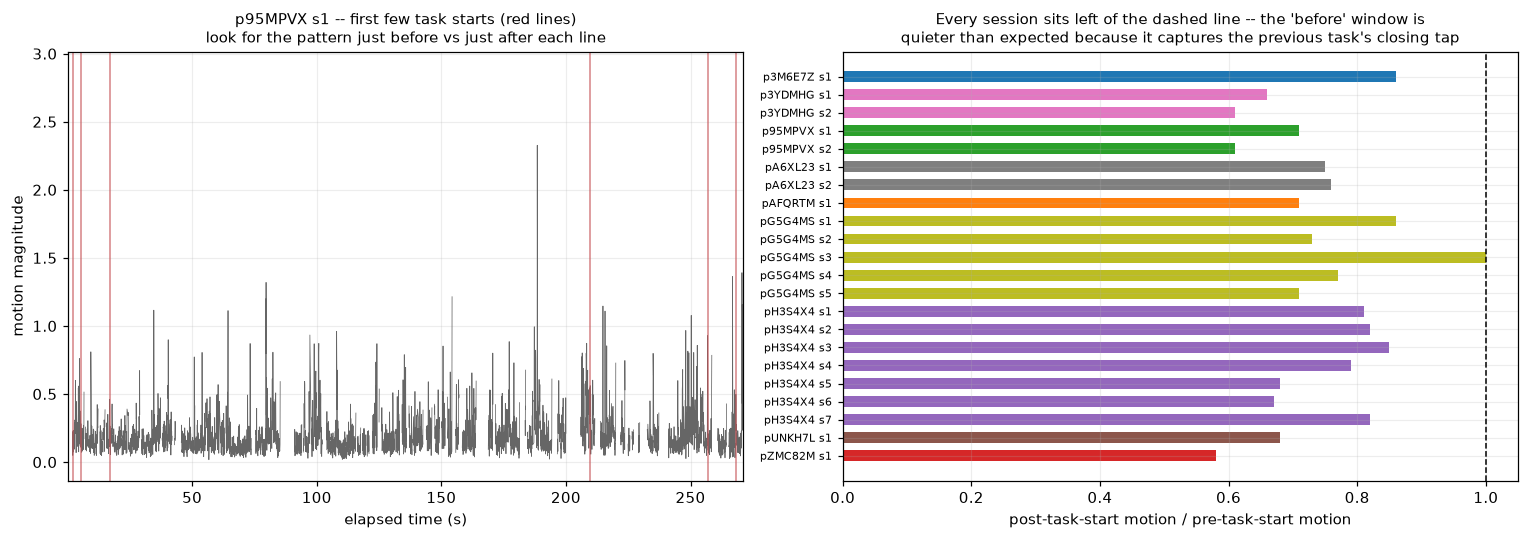

In [11]:
def plot_orienting(orient_df, demo_sid):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    sess = raw.loc[raw['sessionId'] == demo_sid]
    t, mag = motion_magnitude(sess)
    starts = task_start_times(sess)[:6]
    tb, mb = break_on_gaps(t, mag)
    ax.plot(tb, mb, lw=0.5, color='0.4')
    for s0 in starts:
        ax.axvline(s0, color='#c44e52', lw=1, alpha=0.7)
    ax.set_xlim(starts[0] - 2, starts[-1] + 3)
    ax.set_xlabel("elapsed time (s)"); ax.set_ylabel("motion magnitude")
    ax.set_title(f"{SESSION_LABEL[demo_sid]} -- first few task starts (red lines)\n"
                 "look for the pattern just before vs just after each line", fontsize=10)

    ax = axes[1]
    d = orient_df.dropna(subset=['post_pre_ratio']).sort_values(['p', 'session'])
    y = np.arange(len(d))
    ax.barh(y, d['post_pre_ratio'], color=[pcolor(p) for p in d['p']], height=0.6)
    ax.axvline(1.0, color='k', ls='--', lw=1)
    ax.set_yticks(y); ax.set_yticklabels(d['session'], fontsize=7); ax.invert_yaxis()
    ax.set_xlabel("post-task-start motion / pre-task-start motion")
    ax.set_title("Every session sits left of the dashed line -- the 'before' window is\n"
                 "quieter than expected because it captures the previous task's closing tap",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


_demo = max(_clean_sids, key=lambda sid: raw.loc[raw['sessionId'] == sid, 'tRelMs'].max())
plot_orienting(orient_df, _demo)

## 7. Per-participant summary

In [12]:
summary = pd.DataFrame(index=PARTICIPANTS)
summary['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
summary['steadiness_median'] = steady_df.groupby('p')['steadiness_sd'].median().reindex(PARTICIPANTS)
summary['tremor_power_median'] = steady_df.groupby('p')['tremor_power_8to9_5hz'].median().reindex(PARTICIPANTS)
summary['coupling_active_median'] = coup_df.groupby('p')['coupling_active'].median().reindex(PARTICIPANTS)
summary['coupling_idle_median'] = coup_df.groupby('p')['coupling_idle'].median().reindex(PARTICIPANTS)
summary['normalised_jerk_median'] = jerk_df.groupby('p')['normalised_jerk'].median().reindex(PARTICIPANTS)
summary['orienting_ratio_median'] = orient_df.groupby('p')['post_pre_ratio'].median().reindex(PARTICIPANTS)

print("Blank cells mean the quantity could not be computed for that person -- usually a")
print("participant whose only sessions were excluded as gap-affected or singular.\n")
print(summary.round(2).to_string())

Blank cells mean the quantity could not be computed for that person -- usually a
participant whose only sessions were excluded as gap-affected or singular.

         sessions  steadiness_median  tremor_power_median  coupling_active_median  coupling_idle_median  normalised_jerk_median  orienting_ratio_median
p3M6E7Z         1               0.09                 0.10                     NaN                   NaN                   12.12                    0.86
pAFQRTM         1               0.12                 0.10                    0.01                  0.01                   12.02                    0.71
p95MPVX         2               0.16                 0.15                    0.60                  0.61                   11.42                    0.66
pZMC82M         1               0.28                 0.07                     NaN                   NaN                   12.26                    0.58
pH3S4X4         7               0.12                 0.08                    0.68  

## 8. Open questions

- **The task-transition window (Section 6) needs a redesign before it can test the
  orienting-response question at all.** As built, every session shows the "before" window
  quieter than expected — traced to the "before" window capturing the tap that closes the
  previous task, not a genuine quiet baseline. The question of whether people show a
  physical reaction to a new task remains open; this specific measurement can't yet answer
  it either way.
- **Normalised jerk (Section 4) varies narrowly across the whole cohort** (roughly a 25%
  range around the median, far tighter than any other measure here), which is more
  consistent with sample-to-sample sensor noise dominating the calculation than with
  genuine between-person differences in movement smoothness. The standard fix — low-pass
  filtering before differentiating — was not applied and should be, before this measure is
  trusted at all.
- **The tremor-band measurement is close to the limit of what a 20Hz sensor can honestly
  say.** The physiological tremor band (8-12Hz) straddles the Nyquist ceiling; treat that
  column as a coarse indicator throughout, not a precise reading.
- **None of the five metrics in this notebook have yet been checked for within-person
  replication** the way mean-reversion half-life was in the previous version. That check —
  does a person's own repeat sessions agree with each other, against the between-person
  spread as a yardstick — is the natural next step before trusting any of them, and matters
  more for steadiness and coupling (Sections 2 and 3) than for the other two, which have
  already turned out to need a design fix before replication is even the right next
  question.
- **The fatigue trend (Section 5) is a within-session question and doesn't need
  between-session replication to be meaningful on its own terms** — but whether *the shape
  of the trend* (rising, flat, falling) is itself a stable trait for a given person, across
  their own repeat sessions, is untested.
- **Coordination (Section 3) was split into active and idle conditions on theoretical
  grounds** — Bernstein's account is specifically about voluntary movement — but the two
  conditions look similar for most sessions in this cohort, which is worth checking
  directly rather than assumed meaningful from the theory alone.
- **Every participant is still on their own device.** As with every notebook in this
  project, none of this distinguishes a person's own signature from their handset's.